# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [4]:
import pandas as pd
import sklearn
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"

### Step 1. Load the data

In [5]:
# pd.read_csv("../../../datasets/Salary Data.csv").head()
df = pd.read_csv(url)
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [6]:
x = "Experience Years"
y = "Salary"

X = df[[x]]
y = df[y]

### Step 2.b print the type of each

In [ ]:
X.dtypes

Experience Years    float64
dtype: object

In [14]:
y.dtypes

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [ ]:
y.dtype #regression

dtype('int64')

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [ ]:
print(df.shape)

print(X.shape)
print(y.shape)

(40, 2)
(40, 1)
(40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [10]:
y.describe()

count        40.000000
mean      74743.625000
std       25947.122885
min       37731.000000
25%       56878.250000
50%       64472.500000
75%       95023.250000
max      122391.000000
Name: Salary, dtype: float64

In [11]:
X.describe()

,Experience Years
count,40.000000
mean,5.152500
std,2.663715
min,1.100000
25%,3.200000
50%,4.600000
75%,6.875000
max,10.500000


### Step 5. Plot the feature vs the target

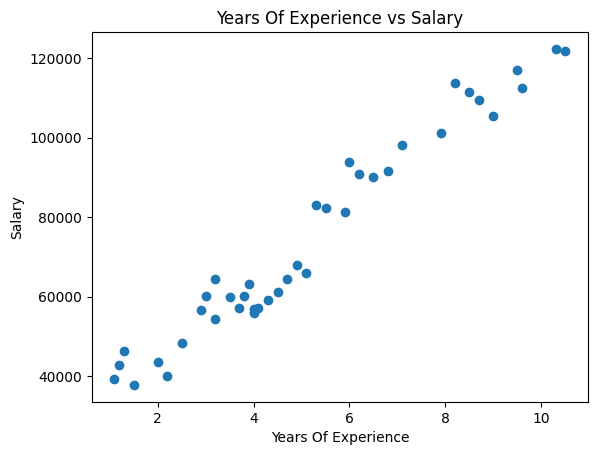

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X,y)
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.title("Years Of Experience vs Salary")
plt.show()


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [ ]:
#Increasing relationship

### Step 7. Initialize a regression model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Step 9.a Train the model on the training set

In [ ]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9291.241637454848
Intercept: 26932.412096354186


### Step 9.c how much salary does a person get with 2 years of experience?

In [ ]:
model.coef_[0] * 2 + model.intercept_

np.float64(45514.89537126388)

### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [ ]:
model.coef_[0] * (6/ 12)

np.float64(4645.620818727424)

### Step 9.e if one has zero experience, then how much is the estimated salary?

In [ ]:
model.intercept_

np.float64(26932.412096354186)

### Step 10. Evaluate the model on the test set

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 39373703.419193625
R2 Score: 0.9174019372663258


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [ ]:
sample_X = X_test[:3]
sample_y = y_test[:3]

predictions = model.predict(sample_X)

print("Predictions:", predictions)
print("Actual:", sample_y.values)

Predictions: [ 74317.74444737  59451.75782745 100333.22103225]
Actual: [ 66029  60000 101302]


### Step 12. Plot the data and the regression line

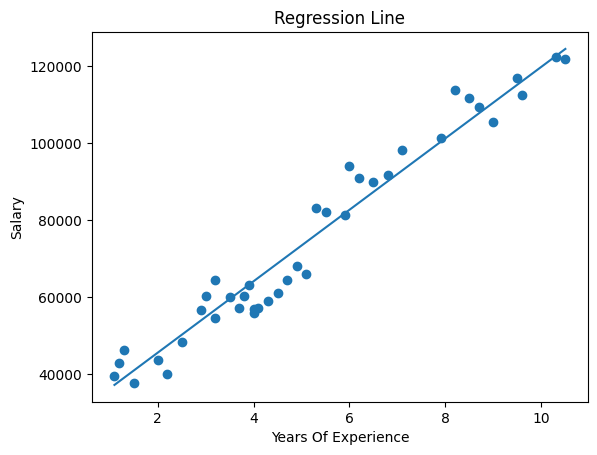

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(X, y)

# Regression line
y_line = model.predict(X)
plt.plot(X, y_line)

plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")

plt.show()